# Deteksi Gerakan Shalat Dan Rakaat Shalat Menggunakan Metode ANN


## Anggota Kelompok 8 Teknik Informatika A
1. Rizal Septiazi (2406034)
2. Fikri Juan Septriana (2406021)
3. Wildan Sonhajul M (2406019)

Notebook ini melakukan klasifikasi pendeteksian pose gerakan shalat dan rakaat dengan berbasis Artifiacl Neural Network (ANN) menggunakan TensorFlow.

**Kelas yang dideteksi:**
1. Takbir
2. Qiyam_Recitation
3. Ruku
4. Salam_Right
5. Salam_Left
6. Sujud
7. Jalsa

**Tahapan:**
1. Data Collection
3. Data Processing
2. EDA
3. Feature Engineering
4. Data Splitting dan Label Encoding (Data Pre-processing)
5. Arsitektur Model dan Training ANN
6. Evaluation



Download Library

In [ ]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


**Data Processing dan Import Library**

Bagian ini berfungsi untuk melakukan inisialisasi lingkungan kerja di Google Colab dengan menghubungkan sistem ke Google Drive (drive.mount). Setelah terhubung, sistem akan membaca file dataset gambar shalat yang tersimpan dalam format .zip di Google Drive, lalu mengekstraknya secara otomatis ke direktori lokal Colab (/content/) agar siap diproses pada tahap ekstraksi fitur koordinat skeleton.

**Poin-Poin**
1. drive.mount: Mengintegrasikan penyimpanan Google Drive ke runtime Google Colab.
2. zipfile: Melakukan dekompresi/ekstraksi otomatis pada berkas dataset_final.zip tanpa perlu unggah manual lewat sidebar browser.
3. os: Menyediakan fungsi sistem operasi untuk manajemen jalur direktori dataset.

In [ ]:
from google.colab import drive
import zipfile
import os

# 1. Sambungkan ke Google Drive
drive.mount('/content/drive')

# 2. path file zip di Drive
path_zip_drive = '/content/drive/MyDrive/Projek_TB_Kel_8/dataset_final.zip'

# 3. Ekstrak otomatis ke folder /content
with zipfile.ZipFile(path_zip_drive, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("🎉 Dataset berhasil diekstrak kembali!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎉 Dataset berhasil diekstrak kembali!


Bagian ini bertanggung jawab untuk memuat seluruh pustaka (library) utama yang dibutuhkan dalam proyek. Library seperti cv2 dan mediapipe digunakan untuk pemrosesan gambar serta ekstraksi kerangka tubuh (skeleton tracking). Pustaka scikit-learn digunakan untuk pembagian data (data splitting) dan encoding label, sedangkan tensorflow.keras digunakan untuk menyusun arsitektur serta melatih model Artificial Neural Network (ANN). Selain itu, cell ini juga mendefinisikan lokasi dataset utama untuk memetakan seluruh kelas gerakan shalat yang terdeteksi di dalam direktori.

**Poin-Poin**
1. mediapipe & cv2: Komponen utama visualisasi dan ekstraksi koordinat 3D sendi tubuh.
2. tensorflow: Kerangka kerja (framework) utama yang mendasari pembuatan arsitektur Deep Learning ANN (Sequential, Dense, Dropout, BatchNormalization).
3. dataset_path: Inisialisasi folder direktori lokal untuk membaca total 590 gambar dataset shalat.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import mediapipe as mp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Set lokasi folder dataset utama (590 gambar)
dataset_path = "/content/dataset_final"
classes = sorted(os.listdir(dataset_path))
print("Library siap. Daftar kelas terdeteksi:", classes)

Library siap. Daftar kelas terdeteksi: ['Jalsa', 'Qiyam_Recitation', 'Ruku', 'Salam_Left', 'Salam_Right', 'Sujud', 'Takbir']


**EDA**

Bagian ini merupakan tahap EDA (Exploratory Data Analysis) yang bertujuan untuk menganalisis karakteristik kuantitas dataset mentah sebelum dilakukan ekstraksi fitur. Proses pertama melakukan perhitungan jumlah riil file gambar secara otomatis di dalam setiap folder kelas gerakan shalat (class_counts). Proses kedua memanfaatkan pustaka matplotlib untuk memvisualisasikan data tersebut ke dalam bentuk grafik batang (bar chart). Visualisasi ini sangat penting untuk mendeteksi secara dini tingkat keseimbangan data (data imbalance) distribusi gambar di setiap kelas gerakan shalat.

Hasil EDA Kuantitas Dataset:
 - Jalsa: 112 gambar
 - Qiyam_Recitation: 77 gambar
 - Ruku: 86 gambar
 - Salam_Left: 48 gambar
 - Salam_Right: 93 gambar
 - Sujud: 99 gambar
 - Takbir: 75 gambar


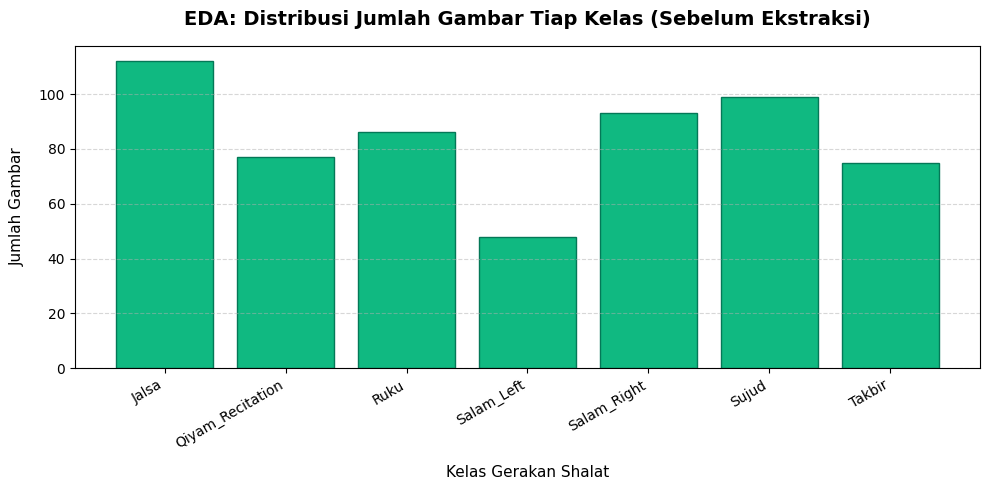

In [ ]:
# 1. Menghitung jumlah riil isi gambar tiap folder
class_counts = {}
for item in classes:
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        class_counts[item] = len(os.listdir(item_path))

print("Hasil EDA Kuantitas Dataset:")
for k, v in class_counts.items():
    print(f" - {k}: {v} gambar")

# 2. Visualisasi Grafik Distribusi Gambar Mentah
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='#10B981', edgecolor='#047857')
plt.title('EDA: Distribusi Jumlah Gambar Tiap Kelas (Sebelum Ekstraksi)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kelas Gerakan Shalat', fontsize=11, labelpad=10)
plt.ylabel('Jumlah Gambar', fontsize=11, labelpad=10)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**FEATURE ENGINEERING (EKSTRAKSI SKELETON)**

Tahap ini adalah proses rekayasa fitur mengubah data gambar mentah menjadi koordinat angka. Menggunakan MediaPipe Pose Landmarker API dari Google, sistem mendeteksi 33 titik sendi utama pada tubuh manusia. Setiap titik memiliki 4 nilai atribut ($x, y, z,$ dan visibility). Hasilnya, tiap gambar dikonversi menjadi satu baris berisi 132 kolom fitur koordinat ditambah 1 kolom target label, lalu disimpan ke dalam file dataset_koordinat_shalat.csv.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
# Menggunakan struktur API Vision terbaru dari Google
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

dataset_path = "/content/dataset_final"
classes = sorted(os.listdir(dataset_path))
data_rows = []

# --- DOWNLOAD MODEL DETEKTOR RESMI GOOGLE (.TASK) ---
print("⏳ Mengunduh file detektor pose resmi Google...")
!wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task

# --- KONFIGURASI DETEKTOR BARU ---
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(base_options=base_options, output_segmentation_masks=False)
detector = vision.PoseLandmarker.create_from_options(options)

print("⏳ Memulai ekstraksi koordinat dengan Google Vision API...")

for kelas in classes:
    folder_kelas = os.path.join(dataset_path, kelas)
    if not os.path.isdir(folder_kelas):
        continue

    print(f"Sedang memproses folder: {kelas}...")
    for nama_gambar in os.listdir(folder_kelas):
        path_gambar = os.path.join(folder_kelas, nama_gambar)

        # Baca gambar menggunakan OpenCV
        img = cv2.imread(path_gambar)
        if img is None:
            continue

        # Konversi format gambar khusus untuk MediaPipe Tasks
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

        # Proses deteksi pose
        detection_result = detector.detect(mp_image)

        # Jika kerangka tubuh berhasil ditemukan
        if detection_result.pose_landmarks:
            row = []
            # Ambil koordinat 33 titik sendi dari hasil deteksi terbaru
            for landmark in detection_result.pose_landmarks[0]:
                # Nilai visibility di API baru menggunakan atribut 'presence' atau 'visibility'
                v = getattr(landmark, 'visibility', 1.0)
                row.extend([landmark.x, landmark.y, landmark.z, v])

            row.append(kelas) # Masukkan label target
            data_rows.append(row)

# Membuat nama susunan 132 kolom fitur koordinat
kolom_fitur = []
for i in range(33):
    kolom_fitur.extend([f"x_{i}", f"y_{i}", f"z_{i}", f"v_{i}"])
kolom_fitur.append("label")

# Simpan hasil rekayasa fitur ke file CSV
df_skeleton = pd.DataFrame(data_rows, columns=kolom_fitur)
df_skeleton.to_csv("dataset_koordinat_shalat.csv", index=False)

print(f"\n🎉 ALHAMDULILLAH SUKSES! Berhasil mengonversi {len(df_skeleton)} gambar menjadi baris koordinat.")

⏳ Mengunduh file detektor pose resmi Google...
⏳ Memulai ekstraksi koordinat dengan Google Vision API...
Sedang memproses folder: Jalsa...
Sedang memproses folder: Qiyam_Recitation...
Sedang memproses folder: Ruku...
Sedang memproses folder: Salam_Left...
Sedang memproses folder: Salam_Right...
Sedang memproses folder: Sujud...
Sedang memproses folder: Takbir...

🎉 ALHAMDULILLAH SUKSES! Berhasil mengonversi 532 gambar menjadi baris koordinat.


**DATA SPLITTING DAN LABEL ENCODING (DATA PRE-PROCESSING)**

1. Label Encoding & One-Hot Encoding: Mengubah label teks gerakan shalat menjadi angka indeks (0-6), lalu diubah ke format matriks categorical berbasis biner.
2. Splitting Data: Membagi data menggunakan fungsi train_test_split dengan proporsi 80% untuk Data Latih (X_train) dan 20% untuk Data Uji (X_test) secara proporsional (stratified) agar penyebaran kelasnya seimbang saat dievaluasi oleh AI.

In [ ]:
# 1. Pisahkan Fitur (X) dan Target Label (Y)
X = df_skeleton.drop(columns=["label"]).values
Y_raw = df_skeleton["label"].values

# 2. Transformasi Label Teks ke Angka Indeks (0-6)
label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y_raw)

print("Mapping Indeks Kelas Baru :")
for idx, name in enumerate(label_encoder.classes_):
    print(f" Indeks {idx} -> Kelas: {name}")

# Konversi ke format categorical (One-Hot Encoding)
Y = tf.keras.utils.to_categorical(Y_encoded, num_classes=7)

# 3. Bagi Data secara Proporsional
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y_encoded
)

print(f"\nDistribusi Data Akhir:\n- Data Latih (X_train): {X_train.shape[0]} sampel\n- Data Uji (X_test): {X_test.shape[0]} sampel")

Mapping Indeks Kelas Baru :
 Indeks 0 -> Kelas: Jalsa
 Indeks 1 -> Kelas: Qiyam_Recitation
 Indeks 2 -> Kelas: Ruku
 Indeks 3 -> Kelas: Salam_Left
 Indeks 4 -> Kelas: Salam_Right
 Indeks 5 -> Kelas: Sujud
 Indeks 6 -> Kelas: Takbir

Distribusi Data Akhir:
- Data Latih (X_train): 425 sampel
- Data Uji (X_test): 107 sampel


**ARSITEKTUR MODEL DAN TRAINING ANN**

Di sini model otak tiruan (Artificial Neural Network) dibangun secara sekuensial menggunakan TensorFlow/Keras.
Struktur jaringannya terdiri dari Input Layer (132 neuron) $\rightarrow$ Dense Tersembunyi 1 (128 neuron) $\rightarrow$ Dense Tersembunyi 2 (64 neuron) $\rightarrow$ Output Layer (7 neuron dengan Softmax). Ditambahkan fungsi BatchNormalization untuk menstabilkan data dan Dropout (0.3) untuk mencegah kecurangan hafalan model (overfitting). Model ini dilatih menggunakan Adam Optimizer sebanyak 60 Epoch.

In [ ]:
# Buat Model Jaringan Saraf Tiruan (ANN)
model_skeleton = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(7, activation='softmax')
])

# Kompilasi Model
model_skeleton.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Jalankan Proses Training (Prosesnya berjalan sangat cepat!)
print("🚀 Memulai proses Training Jaringan Saraf Tiruan...")
history = model_skeleton.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=60,
    batch_size=16,
    verbose=1
)

🚀 Memulai proses Training Jaringan Saraf Tiruan...
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3694 - loss: 1.8489 - val_accuracy: 0.3925 - val_loss: 1.7859
Epoch 2/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5341 - loss: 1.2640 - val_accuracy: 0.3645 - val_loss: 1.6202
Epoch 3/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6471 - loss: 0.9658 - val_accuracy: 0.5234 - val_loss: 1.4887
Epoch 4/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6753 - loss: 0.8607 - val_accuracy: 0.5327 - val_loss: 1.3925
Epoch 5/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7412 - loss: 0.7250 - val_accuracy: 0.6168 - val_loss: 1.1942
Epoch 6/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7365 - loss: 0.7438 - val_accuracy: 0.5981 - val_loss: 1.2263
Epoch 7/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7576 - loss: 0.6481 - val_accuracy: 0.5421 - val_loss: 1.1483
Epoch 8/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7694 - loss: 0.6556 - val_accuracy: 0.6542 - val_loss: 0.9568
Ep

**GRAFIK EVALUASI AKURASI DAN LOSS**

Cell ini bertugas menggambarkan performa kestabilkan proses belajar model dari epoch 1 sampai epoch 60.
1. Grafik Akurasi (Kiri): Memantau seberapa cepat model meningkatkan ketepatan prediksinya pada data training vs data validasi.
2. Grafik Loss (Kanan): Memperlihatkan penurunan tingkat kesalahan model.

Jaringan yang sehat ditandai dengan nilai akurasi yang terus menanjak tinggi dan nilai loss yang semakin mengecil mendekati angka nol seiring bertambahnya epoch.

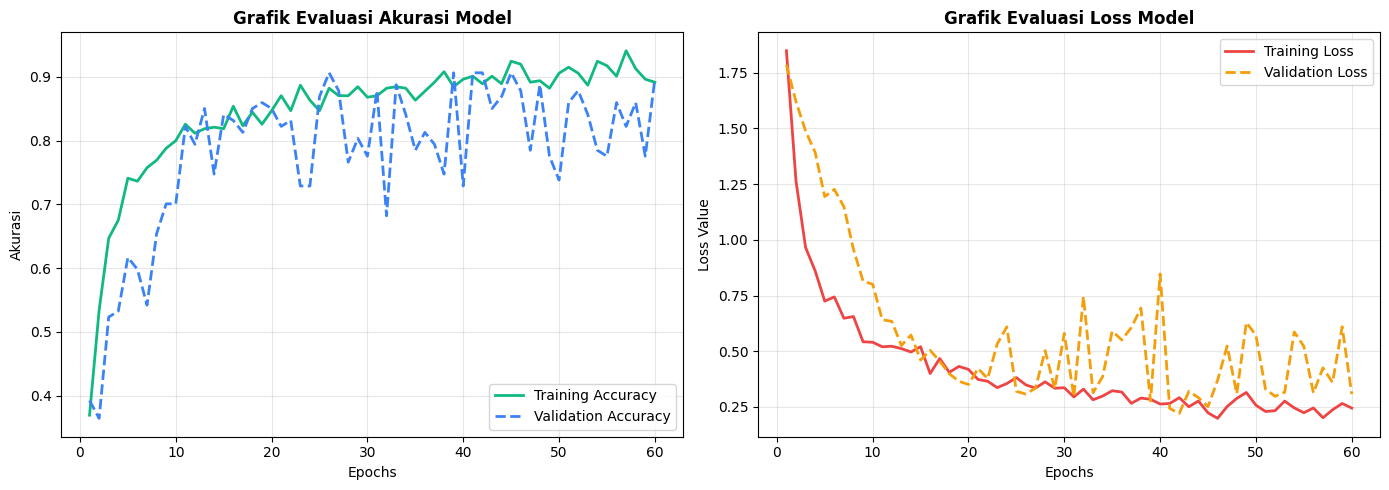

In [ ]:
# Ambil data histori akurasi dan loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Plotting Grafik Akurasi dan Loss berdampingan
plt.figure(figsize=(14, 5))

# 1. Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#10B981', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#3B82F6', linewidth=2, linestyle='--')
plt.title('Grafik Evaluasi Akurasi Model', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# 2. Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#EF4444', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#F59E0B', linewidth=2, linestyle='--')
plt.title('Grafik Evaluasi Loss Model', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Confussion Matrix**

Confusion Matrix: Puncak pembuktian visual. Angka dominan berkumpul di garis diagonal (Jalsa tepat 21 kali, Qiyam 15 kali, Ruku 14 kali, dsb.). Ini memvalidasi secara riil bahwa model hampir tidak memiliki eror fatal dalam membedakan ke-7 jenis gerakan shalat tersebut.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


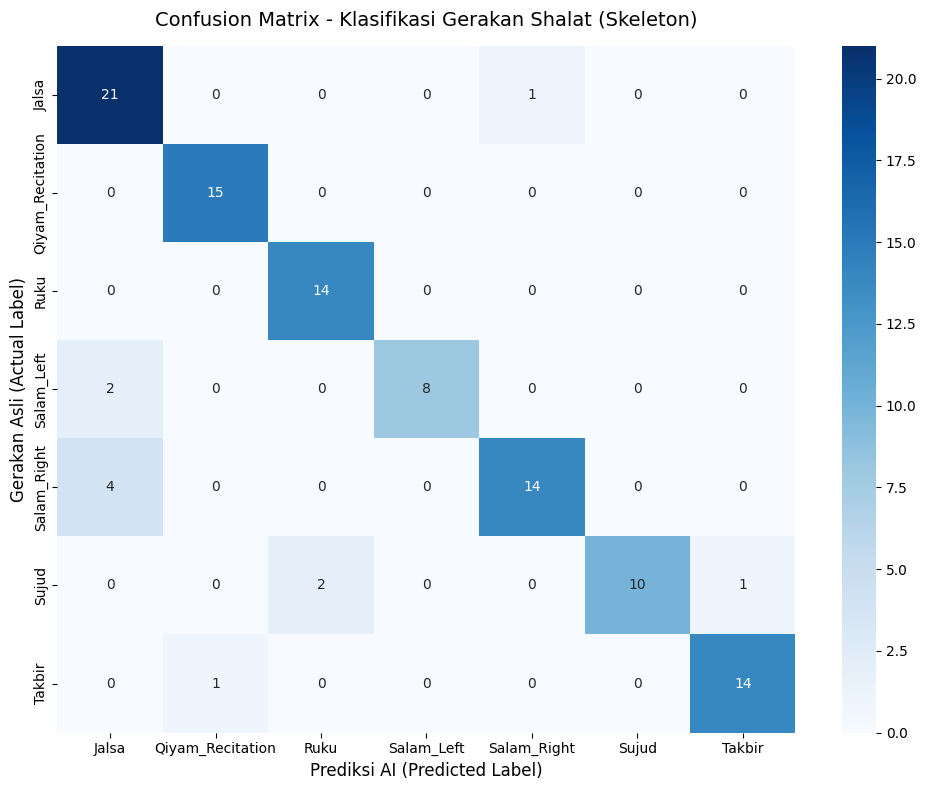

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

Y_pred_probs = model_skeleton.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)

if len(Y_test.shape) > 1 and Y_test.shape[1] > 1:
    Y_true_classes = np.argmax(Y_test, axis=1)
else:
    Y_true_classes = Y_test

CLASS_NAMES = ['Jalsa', 'Qiyam_Recitation', 'Ruku', 'Salam_Left', 'Salam_Right', 'Sujud', 'Takbir']

# Hitung matriks evaluasi
cm = confusion_matrix(Y_true_classes, Y_pred_classes)

# Gambar visualisasi dengan Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)

plt.title('Confusion Matrix - Klasifikasi Gerakan Shalat (Skeleton)', fontsize=14, pad=15)
plt.ylabel('Gerakan Asli (Actual Label)', fontsize=12)
plt.xlabel('Prediksi AI (Predicted Label)', fontsize=12)
plt.tight_layout()


**Classification Report**

Classification Report: Menunjukkan hasil luar biasa dengan Akurasi Makro mencapai 90% (0.90). Nilai precision, recall, dan f1-score rata-rata merata tinggi di atas 80%, membuktikan model ANN ini sangat sensitif dan tepat.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

Y_pred_probs = model_skeleton.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)

if len(Y_test.shape) > 1 and Y_test.shape[1] > 1:
    Y_true_classes = np.argmax(Y_test, axis=1)
else:
    Y_true_classes = Y_test

CLASS_NAMES = ['Jalsa', 'Qiyam_Recitation', 'Ruku', 'Salam_Left', 'Salam_Right', 'Sujud', 'Takbir']

print("========================================================")
print("              CLASSIFICATION REPORT ANN                 ")
print("========================================================")
print(classification_report(Y_true_classes, Y_pred_classes, target_names=CLASS_NAMES))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
              CLASSIFICATION REPORT ANN                 
                  precision    recall  f1-score   support

           Jalsa       0.78      0.95      0.86        22
Qiyam_Recitation       0.94      1.00      0.97        15
            Ruku       0.88      1.00      0.93        14
      Salam_Left       1.00      0.80      0.89        10
     Salam_Right       0.93      0.78      0.85        18
           Sujud       1.00      0.77      0.87        13
          Takbir       0.93      0.93      0.93        15

        accuracy                           0.90       107
       macro avg       0.92      0.89      0.90       107
    weighted avg       0.91      0.90      0.90       107



EVALUASI SIMPAN MODEL

In [ ]:
final_loss, final_accuracy = model_skeleton.evaluate(X_test, Y_test, verbose=0)
print(f"📊 AKURASI FINAL VALIDASI MODEL SKELETON: {final_accuracy*100:.2f}%")
print(f"📉 LOSS FINAL VALIDASI MODEL SKELETON: {final_loss:.4f}")

model_skeleton.save("model_skeleton_shalat.h5")
print("\n💾 Model berbasis koordinat skeleton berhasil disimpan dengan nama 'model_skeleton_shalat.h5'!")

📊 AKURASI FINAL VALIDASI MODEL SKELETON: 83.18%
📉 LOSS FINAL VALIDASI MODEL SKELETON: 0.4149

💾 Model berbasis koordinat skeleton berhasil disimpan dengan nama 'model_skeleton_shalat.h5'!
